# Structure Learning for MNIST with Renormalised Generative Models

Implementation of the MNIST digit classification example from:
> Friston et al. (2025) *From pixels to planning: scale-free active inference.* Front. Netw. Physiol. 5:1521963

## Preprocessing Pipeline (Section: Image compression and compositionality)

From the paper (p.10):
> MNIST images were preprocessed by up-sampling to 32 pixels x 32 pixels, smoothing, and histogram equalization. In addition, they were converted into a format suitable for video processing with three (TrueColor or RGB) channels.

In [1]:
import numpy as np
from jax import numpy as jnp
import matplotlib.pyplot as plt

from preprocess import load_mnist, preprocess
from utils import extract_exemplars

In [2]:
x_train, y_train, x_test, y_test = load_mnist(cache_dir='./mnist_cache')

print(f"Training set: {x_train.shape}, labels: {y_train.shape}")
print(f"Test set:     {x_test.shape}, labels: {y_test.shape}")
print(f"Pixel range:  [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Classes:      {np.unique(np.array(y_train))}")

Training set: (60000, 28, 28), labels: (60000,)
Test set:     (10000, 28, 28), labels: (10000,)
Pixel range:  [0.0, 255.0]
Classes:      [0 1 2 3 4 5 6 7 8 9]


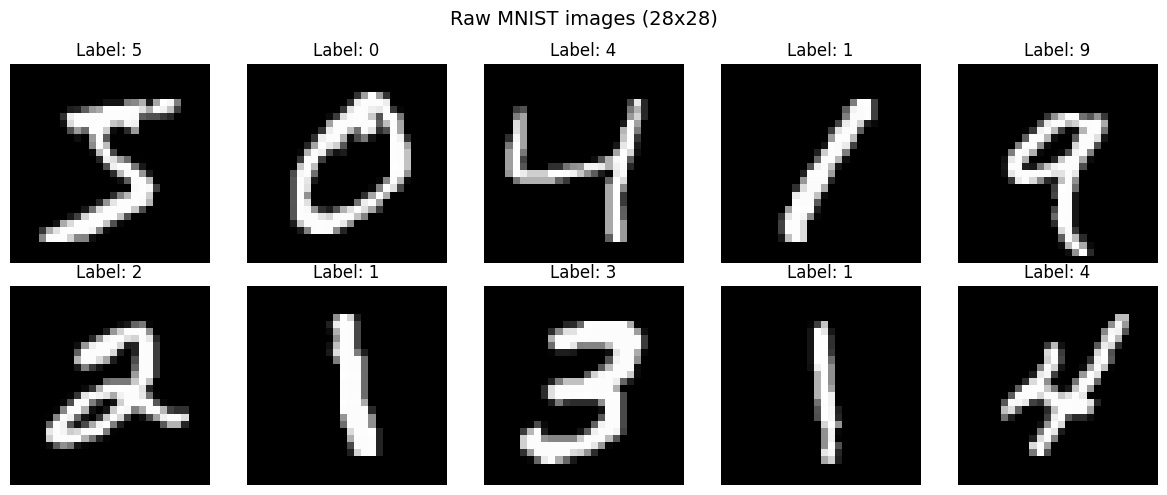

In [3]:
# Show a few raw 28x28 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
fig.suptitle('Raw MNIST images (28x28)', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Preprocess

The full pipeline applies (in order):
1. **Gaussian smoothing** (sigma=0.3) - smooth before upsampling to reduce aliasing
2. **Histogram equalization** - enhance contrast
3. **Bilinear upsampling** 28x28 → 32x32 - makes image divisible into 4x4 patches for the blocking transformation
4. **Convert to RGB** (3 identical channels) - format suitable for video processing extension

Output shape: `(N, 3, 32, 32)`

see preprocess.py for how these functions are implemented.

## 3. Select Structure Learning Exemplars

From the paper (p.10):
> Based on the prior that there can be a dozen ways of writing any given number, the first 13 (Baker's dozen) images of each digit class were used for fast structure learning.

These 130 images (13 per class x 10 classes) are used to build the initial RGM hierarchy via fast structure learning. The remaining images are used for active learning.

In [4]:
M_PER_CLASS = 13  # Baker's dozen
NUM_CLASSES = 10

x_exemplars_raw, y_exemplars, exemplar_idx = extract_exemplars(x_train, y_train, M_PER_CLASS, NUM_CLASSES)
print(f"Exemplar images: {x_exemplars_raw.shape}")
print(f"Per class: {[(y_exemplars == d).sum().item() for d in range(10)]}")

Exemplar images: (130, 28, 28)
Per class: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13]


In [5]:
# Preprocess the exemplars
x_exemplars = preprocess(x_exemplars_raw, target_size=32, sigma=0.3)
print(f"Preprocessed exemplars: {x_exemplars.shape}")

Preprocessed exemplars: (130, 3, 32, 32)


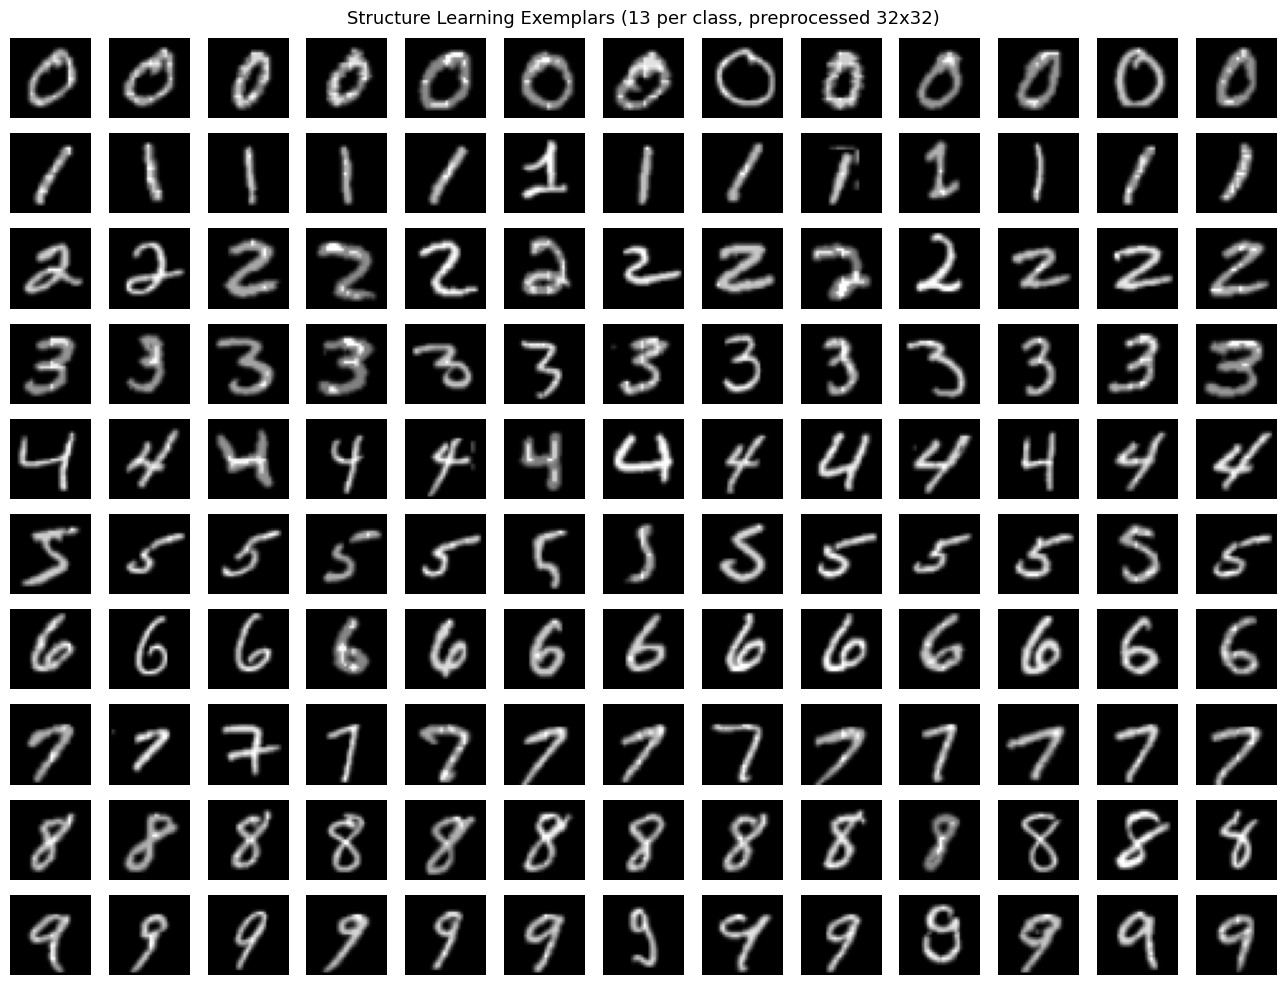

In [6]:
# Display all 130 exemplars organised by class (cf. Figure 4 in the paper)
fig, axes = plt.subplots(NUM_CLASSES, M_PER_CLASS, figsize=(M_PER_CLASS, NUM_CLASSES))
for digit in range(NUM_CLASSES):
    mask = y_exemplars == digit
    digit_imgs = x_exemplars[mask]
    for j in range(M_PER_CLASS):
        axes[digit, j].imshow(digit_imgs[j, 0], cmap='gray')
        axes[digit, j].axis('off')
    axes[digit, 0].set_ylabel(str(digit), rotation=0, fontsize=12, labelpad=15)
fig.suptitle(f'Structure Learning Exemplars ({M_PER_CLASS} per class, preprocessed 32x32)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. SVD Discretisation

From the paper (p.8-10): Images are tessellated into 4x4 patches. Each patch location gets its own SVD basis learned from the structure exemplars. Continuous singular variates are quantised into 7 discrete levels, producing a discrete observation tensor per image. 

The main text in the paper says:

> "Each group is then subject to singular value decomposition, given a training set of images, to identify an orthogonal (spatial) basis set of singular vectors. This grouping is followed by a reduction operator that retains singular variates with large singular values (here, the first 32 principal vectors based on groups of 4 × 4 pixels)."

> "The set of singular variates for each group specifies the pattern for any given image at the corresponding location. The continuous variates can then be quantized to a discrete number of levels (here, seven)."

However the figure 4 caption says:

> "...in this example, the singular variates could take seven discrete values centered on zero for a maximum of 16 singular vectors."

And footnote 7 says:

> "In practice, we use overlapping groups, where the singular value decomposition is applied following weighting by a radial (Gaussian) basis function whose standard deviation is the distance between group centers."

In [7]:
from discretise import DiscretiseConfig, compute_svd_basis, encode_images, decode_observations

config = DiscretiseConfig()
basis = compute_svd_basis(x_exemplars, config)
observations = encode_images(x_exemplars, basis, config)

print(f"SVD basis V:     {basis.V.shape}")
print(f"Bin edges:       {basis.bin_edges.shape}")
print(f"Observations:    {observations.shape}")
print(f"Value range:     [{observations.min()}, {observations.max()}]")

SVD basis V:     (8, 8, 48, 16)
Bin edges:       (8, 8, 16, 8)
Observations:    (130, 8, 8, 16)
Value range:     [0, 6]


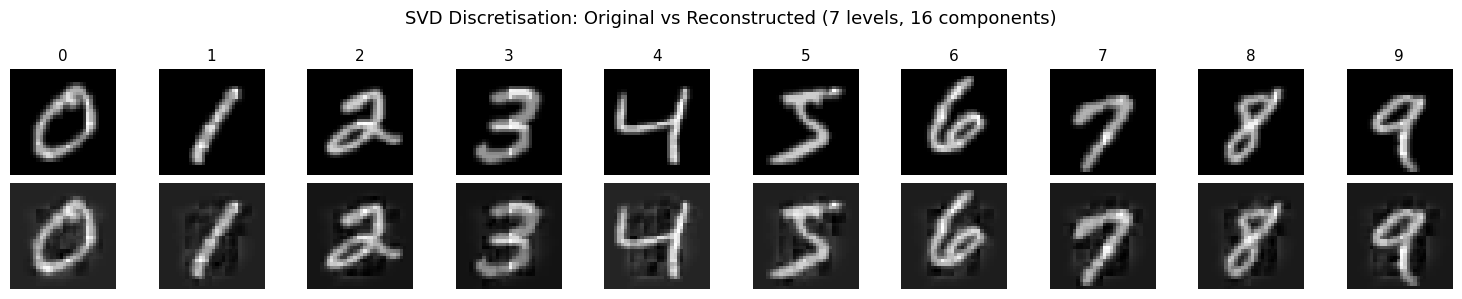

In [8]:
# Reconstruct and compare (cf. Figure 4 right panel) - one of each digit
reconstructed = decode_observations(observations, basis, config)

# Pick the first exemplar of each digit (0-9)
show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 3))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(x_exemplars[idx, 0], cmap='gray')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(reconstructed[idx, 0], cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstructed', fontsize=11)
fig.suptitle('SVD Discretisation: Original vs Reconstructed (7 levels, 16 components)', fontsize=13)
plt.tight_layout()
plt.show()